# 第21篇｜图表美化：颜色 / 字体 / 注释 / 样式

> 这是「数据分析从入门到精通」系列的第 21 篇。图表能画了，但好看吗？这篇来聊图表美化——颜色搭配、字体设置、数据标注、整体样式，让你的图表从"能看"升级到"好看"。

---

嗨，我是小荷～

上一篇我们学了 5 种基础图表，能画出来了。但你有没有觉得默认的图表……有点丑？

数据分析师的报告被老板打开的瞬间，图表第一眼就决定了"这个人专不专业"。默认的蓝色柱状图和精心调过颜色的专业图表，传递的信息量可以差很多。

今天这篇就是"让图表变好看"的系统指南。（萧何当年的账目报告，肯定也是排版工整、重点突出的——否则刘邦哪有耐心看完 😄）

---

## 一、颜色系统

### 1.1 不要用默认颜色

Matplotlib 默认颜色 C0、C1、C2... 够用但不好看。推荐几套配色方案：

**专业数据配色（5色）**：


In [ ]:
palette_pro = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']


**商务蓝灰系**：


In [ ]:
palette_biz = ['#2C3E50', '#5DADE2', '#AED6F1', '#D5D8DC', '#117A65']


**中性高亮系（推荐汇报用）**：


In [ ]:
palette_neutral = ['#BDC3C7', '#BDC3C7', '#E74C3C', '#BDC3C7', '#BDC3C7']
# 用灰色降噪，用红色突出重点


### 1.2 颜色的语义

| 用途 | 推荐颜色 |
|------|---------|
| 正向 / 增长 | `#27AE60` 绿 / `#E74C3C` 红（中国习惯涨=红） |
| 负向 / 下降 | `#27AE60` 绿 |
| 重点强调 | `#E74C3C` 红 或 `#F39C12` 橙 |
| 次要信息 | `#BDC3C7` 浅灰 |
| 背景 / 辅助 | `#ECF0F1` 极浅灰 |

### 1.3 用 colormap 处理连续数据

`applymap`（Pandas 2.1+ 改名为 `map`）可以对 DataFrame 的**每一个格子**应用同一个函数，比如把所有数字格式化成带单位的字符串：


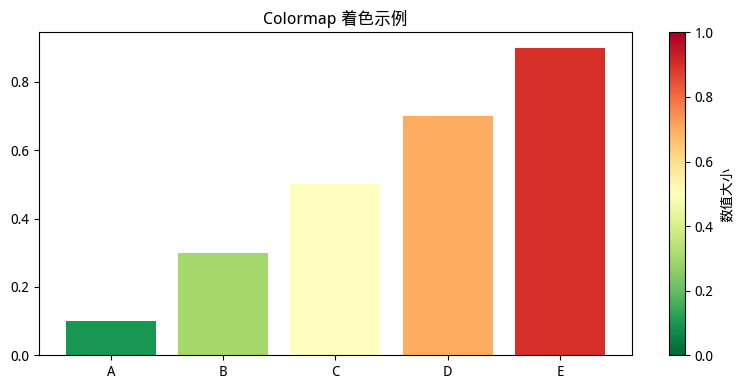

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 热力图风格：绿→黄→红
cmap = plt.cm.RdYlGn_r   # 或 'viridis', 'plasma', 'coolwarm'

values = [0.1, 0.3, 0.5, 0.7, 0.9]
colors = [cmap(v) for v in values]

fig, ax = plt.subplots(figsize=(8, 4))
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
bars = ax.bar(['A','B','C','D','E'], values, color=colors)
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax, label='数值大小')
ax.set_title('Colormap 着色示例')
plt.tight_layout()
plt.show()


---

## 二、字体美化

中文字体是绕不过去的坎，先配置好：


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

# 常用字体大小建议
TITLE_SIZE    = 15    # 图表大标题
LABEL_SIZE    = 12    # 轴标签
TICK_SIZE     = 10    # 刻度文字
ANNOTATION    = 10    # 注释文字
LEGEND_SIZE   = 10    # 图例

# 示例数据
df = pd.DataFrame({'城市': ['北京', '上海', '广州', '北京', '上海', '深圳']})
counts = df['城市'].value_counts()

定义好了字体大小，现在来画一张图看看效果：


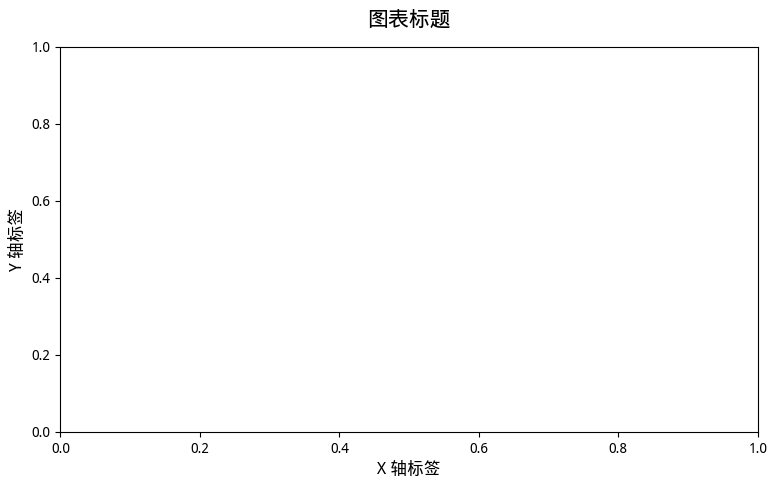

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.set_title('图表标题', fontsize=TITLE_SIZE, fontweight='bold', pad=15)
ax.set_xlabel('X 轴标签', fontsize=LABEL_SIZE)
ax.set_ylabel('Y 轴标签', fontsize=LABEL_SIZE)
ax.tick_params(axis='both', labelsize=TICK_SIZE)


---

## 三、去掉多余边框（去噪）

大多数专业图表只保留两条轴线：


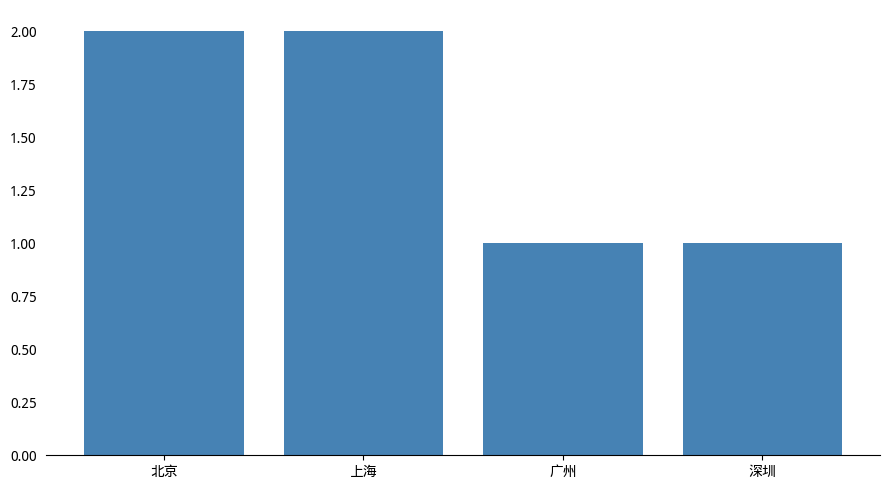

In [44]:
fig, ax = plt.subplots(figsize=(9, 5))

# 更极简：只保留底部
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.set_ticks_position('none')  # 去掉 y 轴刻度线
# 👇 绑数据（加上这条）
ax.bar(counts.index, counts.values, color='steelblue')

plt.tight_layout()
plt.show()


---

## 四、注释与标注

在图表上标注关键信息，让读者一眼看到重点：


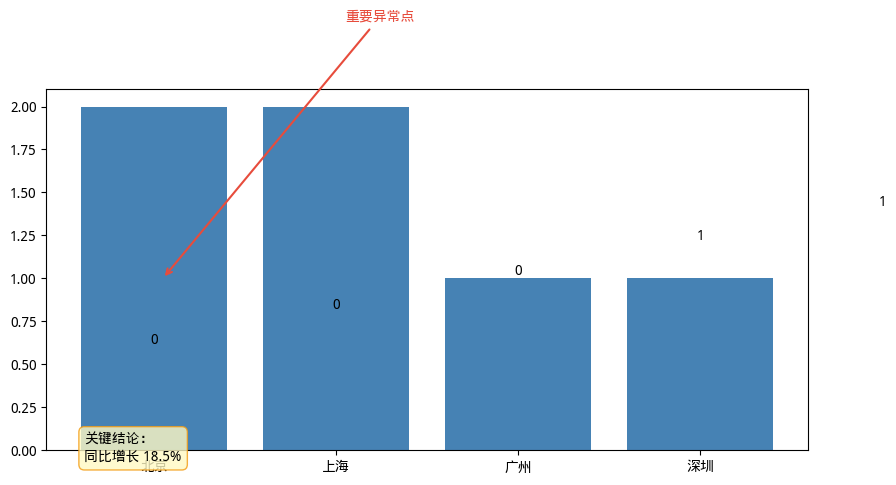

In [54]:
fig, ax = plt.subplots(figsize=(9, 5))
# 👇 绑数据（加上这条）
ax.bar(counts.index, counts.values, color='steelblue')

# 在图上标注具体数值
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
            f'{height:.0f}', ha='center', va='bottom', fontsize=10)

# 箭头注释
x_point=0.05
y_point=1
ax.annotate('重要异常点',
             xy=(x_point, y_point),
             xytext=(x_point + 1, y_point + 1.5),
             arrowprops=dict(
                 arrowstyle='->',
                 color='#E74C3C',
                 lw=1.5
             ),
             fontsize=10,
             color='#E74C3C')

# 文本框注释
ax.text(0.05, 0.05, '关键结论：\n同比增长 18.5%',
         transform=ax.transAxes,
         fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#FFF9C4',
                   edgecolor='#F39C12',
                   alpha=0.8))
plt.tight_layout()
plt.show()

---

## 五、使用内置样式

Matplotlib 内置了不少样式，一键切换风格：


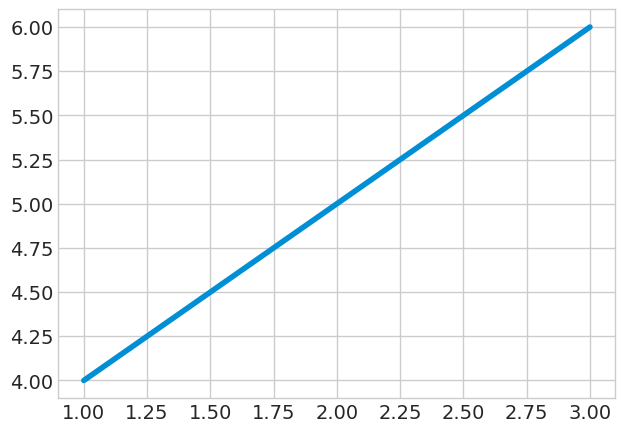

In [55]:
# 推荐的样式
plt.style.use('seaborn-v0_8-whitegrid')   # 最常用，干净的白色背景+灰色网格
plt.style.use('ggplot')                    # 更有设计感
plt.style.use('fivethirtyeight')           # 适合媒体报道风格

# 临时使用某种样式（不影响全局）
with plt.style.context('seaborn-v0_8-whitegrid'):
    fig, ax = plt.subplots()
    ax.plot([1, 2, 3], [4, 5, 6])
    plt.show()


---

## 六、🔧 综合实战：把一张"丑图"变成"专业图"

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


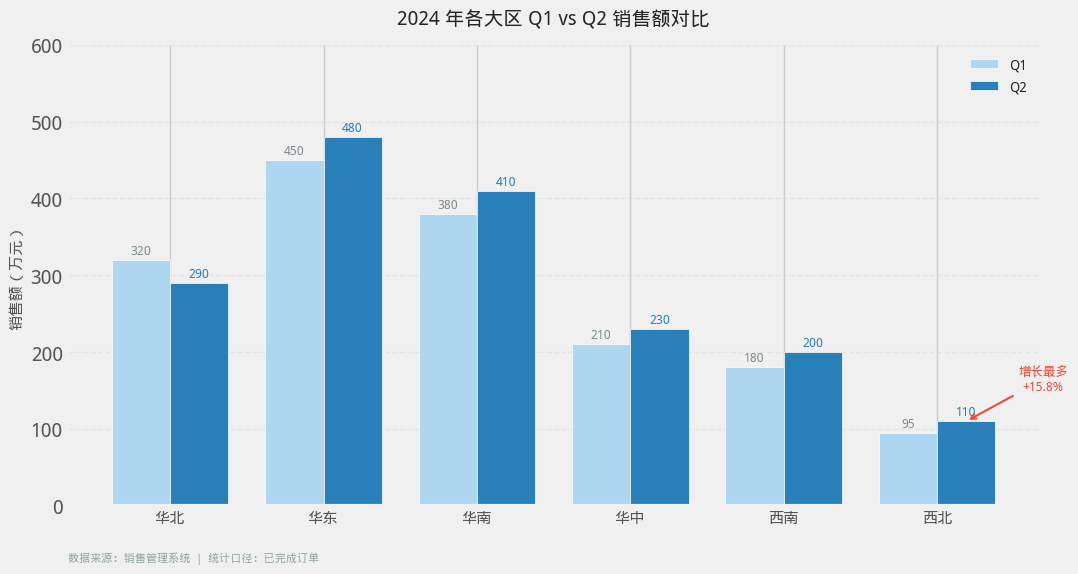

In [56]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

# 数据
regions   = ['华北', '华东', '华南', '华中', '西南', '西北']
sales_q1  = [320, 450, 380, 210, 180, 95]
sales_q2  = [290, 480, 410, 230, 200, 110]

x = np.arange(len(regions))
width = 0.38

# ── 专业版 ──
fig, ax = plt.subplots(figsize=(11, 6))

# 颜色：Q1用浅色，Q2用深色，突出对比
bars1 = ax.bar(x - width/2, sales_q1, width, color='#AED6F1', label='Q1', edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, sales_q2, width, color='#2980B9', label='Q2', edgecolor='white', linewidth=0.5)

# 在柱子上方标注数值
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f'{bar.get_height()}', ha='center', va='bottom', fontsize=9, color='#7F8C8D')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f'{bar.get_height()}', ha='center', va='bottom', fontsize=9, color='#2980B9', fontweight='bold')

# 标注增长最多的区域
q2_growth = [(q2 - q1) / q1 * 100 for q1, q2 in zip(sales_q1, sales_q2)]
max_growth_idx = q2_growth.index(max(q2_growth))
ax.annotate(f'增长最多\n+{max(q2_growth):.1f}%',
             xy=(max_growth_idx + width/2, sales_q2[max_growth_idx]),
             xytext=(max_growth_idx + width/2 + 0.5, sales_q2[max_growth_idx] + 40),
             arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5),
             fontsize=9, color='#E74C3C', ha='center')

# 去边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 轴设置
ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=11)
ax.set_ylabel('销售额（万元）', fontsize=11)
ax.set_ylim(0, max(sales_q2) * 1.25)

# 标题和图例
ax.set_title('2024 年各大区 Q1 vs Q2 销售额对比', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper right', framealpha=0.8)

# 轻量网格
ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

# 副标题（用 text 模拟）
ax.text(0, -0.12, '数据来源：销售管理系统  |  统计口径：已完成订单',
         transform=ax.transAxes, fontsize=8, color='#95A5A6')

plt.tight_layout()
plt.savefig('professional_chart.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 七、📋 美化速查清单

| 要改善的地方 | 方法 |
|------------|------|
| 颜色太丑 | 用自定义 palette，或 colormap |
| 字体太小 | 统一设置 fontsize（标题≥14，标签≥11） |
| 边框太多 | `spines['top/right'].set_visible(False)` |
| 没有数值标注 | `ax.text()` 在柱顶/折线点标值 |
| 没有结论 | 用 `ax.text(transform=ax.transAxes)` 加文本框 |
| 网格太重 | `grid(alpha=0.3, linestyle='--')` |
| 布局混乱 | `plt.tight_layout()` 自动调整 |

---

## 八、📝 小结

图表美化的本质是**信息层级清晰**：

1. **主体颜色** 传递主要信息
2. **弱化辅助元素**（边框、网格）减少视觉噪音
3. **标注关键数值** 让读者不用猜
4. **加结论文字** 让图表自己说话

做到这四点，你的图就已经超过 80% 的分析报告了。

---

## 九、🏋️ 课后练习

1. 把上一篇练习里画的柱状图，用今天的技巧美化：去边框、标数值、突出最高柱子。
2. 尝试用 `seaborn-v0_8-whitegrid` 风格重新画折线图，感受样式变化。
3. 在你的折线图上，用文本框标注一个关键结论（比如"环比增速最快的月份"）。

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 22 篇：Seaborn 入门 — 一行代码出统计图**
>
> 下篇来认识一个「美化图表的神器」—— Seaborn。它是 Matplotlib 的高层封装，一行代码就能出统计图，而且天生好看。

---

*跟着小荷，数据分析路上不迷路～*
